# **ANN 4 – Write a Python Program using Perceptron Neural Network to visualize decision boundaries for linearly separable data.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:

class Perceptron:
    """
    A Perceptron classifier.

    Parameters
    ----------
    input_size : int
        Number of features in the input data.
    learning_rate : float (default: 0.01)
        The step size for weight updates.
    epochs : int (default: 100)
        The number of passes over the training dataset.

    Attributes
    ----------
    weights : array-like, shape = [1 + input_size]
        Weights after fitting. The first element is the bias.
    errors_ : list
        Number of misclassifications (updates) in each epoch.
    """
    def __init__(self, input_size, learning_rate=0.01, epochs=100):
        # Initialize weights for features + bias term
        self.weights = np.zeros(input_size + 1)
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.errors_ = []

    def _activation(self, x):
        """Step activation function."""
        return 1 if x >= 0.0 else 0

    def predict(self, inputs):
        """
        Predict the class label for a single input sample.
        Returns 1 or 0.
        """
        # Add bias term to the input
        inputs_with_bias = np.insert(inputs, 0, 1)
        
        # Calculate net input (weighted sum)
        summation = np.dot(inputs_with_bias, self.weights)
        return self._activation(summation)

    def train(self, X_train, y_train):
        """
        Trains the Perceptron on the training data.

        Parameters
        ----------
        X_train : array-like, shape = [n_samples, n_features]
            Training vectors.
        y_train : array-like, shape = [n_samples]
            Target values (labels).
        """
        for _ in range(self.epochs):
            errors = 0
            for inputs, label in zip(X_train, y_train):
                prediction = self.predict(inputs)
                update = self.learning_rate * (label - prediction)
                
                # Update weights (weights[0] is the bias)
                self.weights[1:] += update * inputs
                self.weights[0] += update
                
                # Count misclassifications
                errors += int(update != 0.0)
            self.errors_.append(errors)
            # Stop if the model has converged
            if errors == 0:
                break
        return self

In [3]:
def plot_decision_regions(X, y, classifier, resolution=0.02):
    """
    Plots the decision boundary and data points for a 2D classifier.
    """
    # Setup marker generator and color map
    markers = ('s', 'x')
    colors = ('red', 'blue')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    x2_min, x2_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    # Use a vectorized prediction
    Z_flat = np.array([classifier.predict(x) for x in np.array([xx1.ravel(), xx2.ravel()]).T])
    Z = Z_flat.reshape(xx1.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='upper left')
    plt.title('Perceptron Decision Regions')
    plt.grid(True)
    plt.show()

Training complete. Final weights (Bias, W1, W2): [-0.1         0.10980635  0.0853187 ]


C:\Users\omshi\AppData\Local\Temp\ipykernel_3312\3645694856.py:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


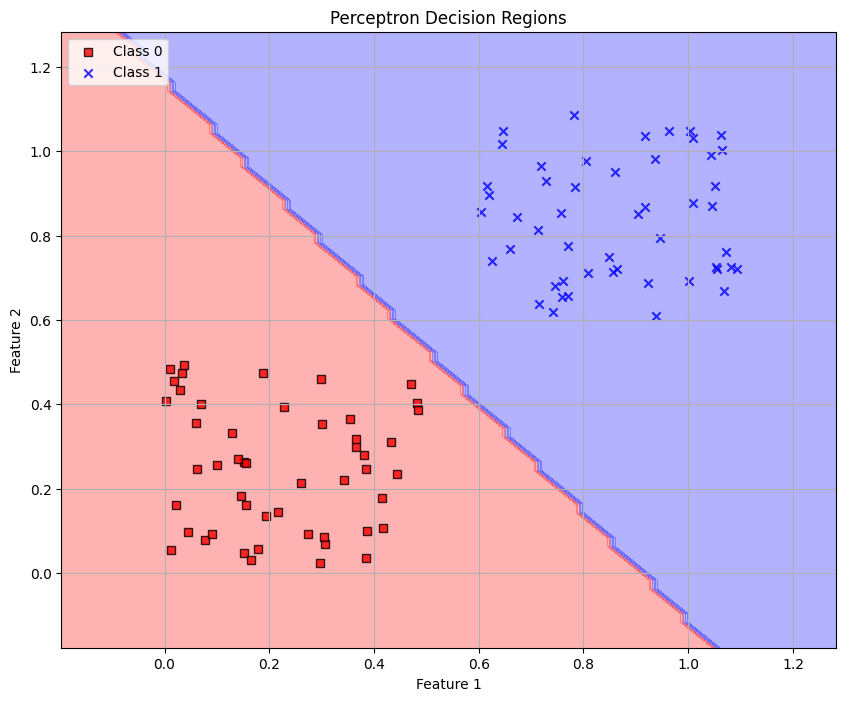

In [4]:
# --- Main execution block ---

if __name__ == "__main__":
    # 1. Generate linearly separable synthetic data
    np.random.seed(42) # for reproducibility
    class_0 = np.random.rand(50, 2) * 0.5
    class_1 = (np.random.rand(50, 2) * 0.5) + 0.6 # Ensure clear separation

    X = np.concatenate((class_0, class_1))
    y = np.array([0] * 50 + [1] * 50)

    # 2. Train the Perceptron
    perceptron = Perceptron(input_size=2, epochs=100, learning_rate=0.1)
    perceptron.train(X, y)
    print(f"Training complete. Final weights (Bias, W1, W2): {perceptron.weights}")

    # 3. Visualize the results
    plot_decision_regions(X, y, classifier=perceptron)